<a href="https://colab.research.google.com/github/Dpythonl/Dpythonl/blob/main/DIGITAL_HEALTH_TWIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

num_users = 50
num_days = 120

data = []

for user in range(num_users):

    baseline_rhr = np.random.normal(63,5)
    baseline_hrv = np.random.normal(42,10)
    baseline_sleep = np.random.normal(7.2,0.7)
    baseline_steps = np.random.normal(8000,2000)
    baseline_stress = np.random.normal(28,8)

    for day in range(num_days):

        sleep_hours = baseline_sleep + np.random.normal(0,0.5)
        steps = baseline_steps + np.random.normal(0,1500)
        stress_score = baseline_stress + np.random.normal(0,5)

        resting_hr = baseline_rhr + 0.3*(stress_score/10) - 0.4*(sleep_hours-7) + np.random.normal(0,1)

        hrv = baseline_hrv - 0.6*(resting_hr-baseline_rhr) + 0.5*(sleep_hours-7) + np.random.normal(0,3)

        active_minutes = steps/200 + np.random.normal(0,5)

        calories = 1800 + steps*0.04 + np.random.normal(0,80)

        sleep_score = 70 + 5*(sleep_hours-7) - 0.3*(stress_score-30) + np.random.normal(0,3)
        sleep_score = max(50, min(95, sleep_score))

        spo2 = np.random.normal(97,1)

        data.append([
            user,
            day,
            resting_hr,
            hrv,
            sleep_hours,
            sleep_score,
            steps,
            active_minutes,
            stress_score,
            spo2,
            calories
        ])

columns = [
"user_id",
"day",
"resting_hr",
"hrv",
"sleep_hours",
"sleep_score",
"steps",
"active_minutes",
"stress_score",
"spo2",
"calories"
]

df = pd.DataFrame(data, columns=columns)

In [ ]:
df.head()

,user_id,day,resting_hr,hrv,sleep_hours,sleep_score,steps,active_minutes,stress_score,spo2,calories
0,0,0,67.487146,53.616971,8.352309,75.706588,9270.500559,47.109371,32.636276,97.214183,2148.821382
1,0,1,67.020170,50.856014,7.199946,70.371606,10359.267787,54.009112,29.253816,96.298770,2210.177786
2,0,2,66.992967,51.919328,8.290411,77.237433,11978.086529,59.676810,29.613119,97.975906,2338.681811
3,0,3,67.393044,41.275599,7.741846,76.840447,11545.336726,61.661122,27.041236,97.364633,2292.317380
4,0,4,66.980095,47.492901,7.735244,77.530237,8342.071202,24.785177,27.258530,96.776603,2103.533015


In [ ]:
df.to_csv("fitbit_digital_twin_data.csv", index=False)

In [ ]:
df.shape

(6000, 11)

In [ ]:
df = df.sort_values(["user_id","day"])
df.head()

,user_id,day,resting_hr,hrv,sleep_hours,sleep_score,steps,active_minutes,stress_score,spo2,calories
0,0,0,67.487146,53.616971,8.352309,75.706588,9270.500559,47.109371,32.636276,97.214183,2148.821382
1,0,1,67.020170,50.856014,7.199946,70.371606,10359.267787,54.009112,29.253816,96.298770,2210.177786
2,0,2,66.992967,51.919328,8.290411,77.237433,11978.086529,59.676810,29.613119,97.975906,2338.681811
3,0,3,67.393044,41.275599,7.741846,76.840447,11545.336726,61.661122,27.041236,97.364633,2292.317380
4,0,4,66.980095,47.492901,7.735244,77.530237,8342.071202,24.785177,27.258530,96.776603,2103.533015


In [ ]:
baseline_days = 14

baseline = df[df["day"] <= baseline_days].groupby("user_id").mean()
baseline.head()

df = df.merge(baseline, on="user_id", suffixes=("","_baseline"))

df["rhr_dev"] = df["resting_hr"] - df["resting_hr_baseline"]
df["hrv_dev"] = df["hrv"] - df["hrv_baseline"]
df["sleep_dev"] = df["sleep_hours"] - df["sleep_hours_baseline"]
df["stress_dev"] = df["stress_score"] - df["stress_score_baseline"]

In [ ]:
df[["rhr_dev","hrv_dev","sleep_dev","stress_dev"]].head()

,rhr_dev,hrv_dev,sleep_dev,stress_dev
0,-0.218557,4.495921,0.595086,5.303689
1,-0.685533,1.734964,-0.557277,1.921228
2,-0.712736,2.798278,0.533187,2.280532
3,-0.312659,-7.845451,-0.015378,-0.291352
4,-0.725608,-1.628149,-0.021980,-0.074058


In [ ]:
df["strain"] = (
    0.3 * df["rhr_dev"]
    -0.3 * df["hrv_dev"]
    -0.2 * df["sleep_dev"]
    +0.2 * df["stress_dev"]
)

In [ ]:
df[["strain"]].head()

,strain
0,-0.472623
1,-0.230448
2,-0.703835
3,2.204643
4,0.260347


In [ ]:
df["instability"] = (df["strain"] > 1).astype(int)

In [ ]:
df[["strain","instability"]].head()

,strain,instability
0,-0.472623,0
1,-0.230448,0
2,-0.703835,0
3,2.204643,1
4,0.260347,0


In [ ]:
df["risk_next_7_days"] = df.groupby("user_id")["instability"].shift(-7)

In [ ]:
df = df.dropna()

In [ ]:
df.shape

(5650, 28)

In [ ]:
features = [
    "resting_hr",
    "hrv",
    "sleep_hours",
    "sleep_score",
    "steps",
    "active_minutes",
    "stress_score",
    "strain"
]

X = df[features]
y = df["risk_next_7_days"]

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05
)

model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
df["risk_probability"] = model.predict_proba(X)[:,1]

In [ ]:
df[["risk_probability"]].head()

,risk_probability
0,0.327946
1,0.288580
2,0.349983
3,0.315219
4,0.211664


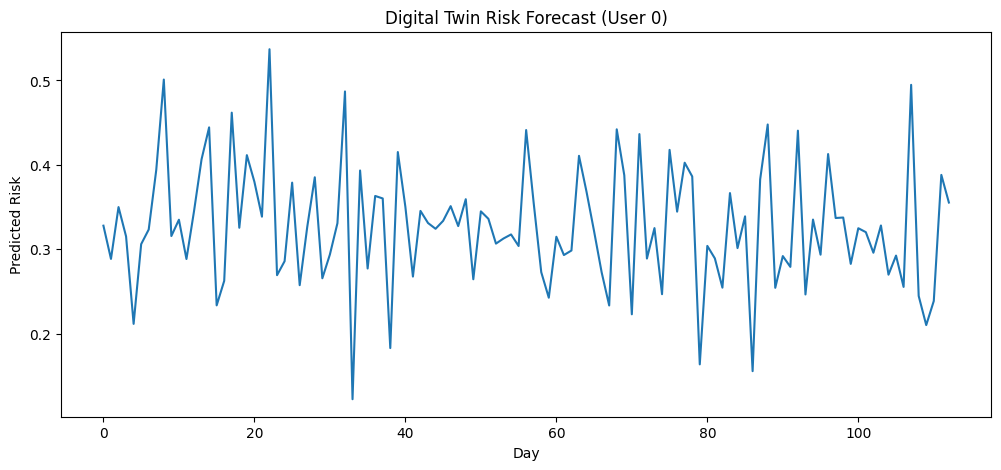

In [ ]:
import matplotlib.pyplot as plt

user0 = df[df["user_id"] == 0]

plt.figure(figsize=(12,5))
plt.plot(user0["day"], user0["risk_probability"])
plt.xlabel("Day")
plt.ylabel("Predicted Risk")
plt.title("Digital Twin Risk Forecast (User 0)")
plt.show()

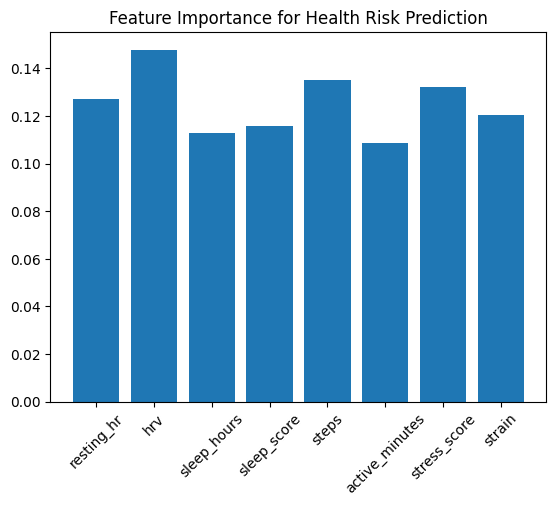

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance for Health Risk Prediction")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.715929203539823


In [ ]:
print(df.columns)

Index(['user_id', 'day', 'resting_hr', 'hrv', 'sleep_hours', 'sleep_score',
       'steps', 'active_minutes', 'stress_score', 'spo2', 'calories',
       'day_baseline', 'resting_hr_baseline', 'hrv_baseline',
       'sleep_hours_baseline', 'sleep_score_baseline', 'steps_baseline',
       'active_minutes_baseline', 'stress_score_baseline', 'spo2_baseline',
       'calories_baseline', 'rhr_dev', 'hrv_dev', 'sleep_dev', 'stress_dev',
       'strain', 'instability', 'risk_next_7_days', 'risk_probability'],
      dtype='object')


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

SEQ_LEN = 7

features = [
    "sleep_hours","steps","resting_hr","hrv",
    "stress_score","active_minutes","sleep_score","strain",

    "hrv_dev","sleep_dev","stress_dev",
    "instability"
]

scaler = MinMaxScaler()
lstm_model = None

In [ ]:


from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

def prepare_lstm_data(df):

    df = df.sort_values(by=["user_id", "day"]).copy()
    df["risk_probability"] = target_scaler.fit_transform(
    df[["risk_probability"]]
)

    df[features] = feature_scaler.fit_transform(df[features])


    df["risk_probability"] = target_scaler.fit_transform(
        df[["risk_probability"]]
    )

    return df

In [ ]:


def create_sequences(df, seq_len=SEQ_LEN, target="risk_probability"):
    X, y = [], []

    for user in df["user_id"].unique():
        user_df = df[df["user_id"] == user]


        for i in range(len(user_df) - seq_len):
            seq = user_df[features].iloc[i:i+seq_len].values
            target_value = user_df[target].iloc[i+seq_len]

            X.append(seq)
            y.append(target_value)

    return np.array(X), np.array(y)

In [ ]:


def train_lstm(df):

    global lstm_model

    df = prepare_lstm_data(df)
    X_seq, y_seq = create_sequences(df)

    split = int(0.8 * len(X_seq))

    X_train, X_test = X_seq[:split], X_seq[split:]
    y_train, y_test = y_seq[:split], y_seq[split:]

    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, len(features))))
    model.add(Dropout(0.2))
    model.add(LSTM(32))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
    optimizer='adam',
    loss='mse',   # or 'mae'
    metrics=['mae']
)
    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_test, y_test)
    )

    lstm_model = model

    return model

In [ ]:


def predict_next(seq):

    seq = np.expand_dims(seq, axis=0)

    pred_scaled = lstm_model.predict(seq, verbose=0)[0][0]


    pred_actual = target_scaler.inverse_transform([[pred_scaled]])[0][0]

    return pred_actual


def forecast_future(seq, steps=7):

    seq = seq.copy()
    preds = []

    for _ in range(steps):

        pred = predict_next(seq)
        preds.append(pred)


        new_row = seq[-1].copy()


        new_row[0] = pred

        seq = np.vstack([seq[1:], new_row])

    return preds

In [ ]:


lstm_model = train_lstm(df)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0114 - mae: 0.0804 - val_loss: 0.0129 - val_mae: 0.0819
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0076 - mae: 0.0671 - val_loss: 0.0129 - val_mae: 0.0841
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0074 - mae: 0.0663 - val_loss: 0.0133 - val_mae: 0.0838
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0071 - mae: 0.0652 - val_loss: 0.0134 - val_mae: 0.0862
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0071 - mae: 0.0653 - val_loss: 0.0136 - val_mae: 0.0840
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0070 - mae: 0.0648 - val_loss: 0.0135 - val_mae: 0.0862
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0068 - mae: 0.0634 - val_loss: 0.0135 - val_mae: 0.0854
Epoch 8/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0066 - mae: 0.0628 - val_loss: 0.0145 - val_mae: 0.0871
Epoch 9/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.00

In [ ]:
def get_user_input():
    print("\n--- Enter Your Daily Health Metrics ---")

    return {
        "sleep_hours": float(input("Sleep Hours (e.g. 6.5): ")),
        "steps": int(input("Steps (e.g. 8000): ")),
        "resting_hr": int(input("Resting Heart Rate (e.g. 70): ")),
        "hrv": int(input("HRV (e.g. 50): ")),
        "stress_score": int(input("Stress Score (0-100): ")),
        "active_minutes": int(input("Active Minutes (e.g. 45): ")),
        "sleep_score": int(input("Sleep Score (0-100): ")),
        "strain": int(input("Strain (e.g. 10): "))
    }

In [ ]:
def predict_user_risk(model, user_input, features):
    import pandas as pd
    X = pd.DataFrame([user_input])[features]
    return model.predict_proba(X)[0][1]

In [ ]:
def adjust_risk(risk, input_data):
    penalty = 0

    if input_data["stress_score"] > 70:
        penalty += 0.15

    if input_data["resting_hr"] > 90:
        penalty += 0.10

    if input_data["steps"] < 2000:
        penalty += 0.10

    if input_data["sleep_hours"] < 6:
        penalty += 0.10

    return min(risk + penalty, 1.0)

In [ ]:
def health_score(risk):
    return int((1 - risk) * 100)

In [ ]:
def risk_label(risk):
    if risk < 0.25:
        return "LOW RISK"
    elif risk < 0.5:
        return "MODERATE RISK"
    else:
        return "HIGH RISK"

In [ ]:
def simulate_future(df, input_data, model, features, user_id=1, days=7):
    import pandas as pd

    last_day = df[df["user_id"] == user_id]["day"].max()

    future_rows = []
    current_input = input_data.copy()

    for i in range(days):
        risk = predict_user_risk(model, current_input, features)
        risk = adjust_risk(risk, current_input)

        future_rows.append({
            "user_id": user_id,
            "day": last_day + i + 1,
            "risk_probability": risk
        })


        current_input["stress_score"] = max(0, min(100, current_input["stress_score"] - 1))
        current_input["steps"] += 200

    return pd.DataFrame(future_rows)

In [ ]:
def plot_with_future(df, future_df, user_id):
    import matplotlib.pyplot as plt

    past = df[df["user_id"] == user_id]

    plt.figure(figsize=(10,5))


    plt.plot(past["day"], past["risk_probability"],
             linewidth=2, label="Past")


    plt.plot(future_df["day"], future_df["risk_probability"],
             linestyle="--", linewidth=2, label="Future")


    plt.scatter(future_df["day"].iloc[-1],
                future_df["risk_probability"].iloc[-1],
                s=120)

    plt.text(future_df["day"].iloc[-1],
             future_df["risk_probability"].iloc[-1] + 0.02,
             "Predicted", ha='center')

    plt.title("Health Risk Forecast", weight="bold")
    plt.xlabel("Day")
    plt.ylabel("Risk Probability")
    plt.legend()

    plt.show()

In [ ]:
def plot_user_snapshot(user_input):
    import matplotlib.pyplot as plt

    labels = list(user_input.keys())
    values = list(user_input.values())

    plt.figure(figsize=(8,5))
    plt.barh(labels, values)

    plt.title("Your Health Metrics Snapshot", weight="bold")
    plt.xlabel("Value")

    plt.show()

In [ ]:
def plot_feature_importance(model, features):
    importance = model.feature_importances_

    import matplotlib.pyplot as plt

    plt.figure(figsize=(8,5))
    plt.barh(features, importance)

    plt.title("Key Drivers of Health Risk", weight="bold")
    plt.xlabel("Importance Score")

    plt.show()

In [ ]:
def plot_intervention_effect(original_risk, new_risk):
    import matplotlib.pyplot as plt

    labels = ["Current", "Improved"]
    values = [original_risk, new_risk]

    plt.figure(figsize=(5,4))
    plt.bar(labels, values)

    plt.title("Impact of Lifestyle Improvement", weight="bold")
    plt.ylabel("Risk")

    plt.show()

In [ ]:
def explain_with_impact(model, user_input, features):
    import pandas as pd

    base = predict_user_risk(model, user_input, features)

    impacts = {}

    for feature in features:
        temp = user_input.copy()


        if isinstance(temp[feature], (int, float)):
            temp[feature] = temp[feature] * 0.9

        new_risk = predict_user_risk(model, temp, features)

        impacts[feature] = base - new_risk


    impacts = dict(sorted(impacts.items(), key=lambda x: abs(x[1]), reverse=True))

    return impacts

In [ ]:

user_input = get_user_input()



base_risk = predict_user_risk(model, user_input, features)
current_risk = adjust_risk(base_risk, user_input)

print("\n📊 CURRENT HEALTH STATUS")
print("Predicted Risk:", round(current_risk, 3))
print("Health Score:", health_score(current_risk))
print("Status:", risk_label(current_risk))

original_risk = current_risk



best_risk = current_risk
best_input = user_input.copy()

for stress_drop in [10, 20, 30]:
    for step_increase in [1000, 2000, 3000]:
        for sleep_add in [0.5, 1, 1.5]:

            temp = user_input.copy()

            temp["stress_score"] = max(0, temp["stress_score"] - stress_drop)
            temp["steps"] += step_increase
            temp["sleep_hours"] += sleep_add

            risk = predict_user_risk(model, temp, features)
            risk = adjust_risk(risk, temp)

            if risk < best_risk:
                best_risk = risk
                best_input = temp.copy()

# Final optimized result
new_risk = best_risk
improved_input = best_input


future_df = simulate_future(df, user_input, model, features)

print("\n🚀 OPTIMIZED HEALTH PLAN")
print("Original Risk:", round(original_risk, 3))
print("Improved Risk:", round(new_risk, 3))

print("\nSuggested Changes:")
for key in user_input:
    if user_input[key] != improved_input[key]:
        print(f"{key}: {user_input[key]} → {improved_input[key]}")


# ===============================
# 6. AI EXPLANATION
# ===============================
reasons, suggestions = sk(user_input)

print("\n⚠️ Why your risk is high:")
for r in reasons:
    print("-", r)

print("\n✅ Recommended improvements:")
for s in suggestions:
    print("-", s)

# ===============================
# 🧠 AI PERSONALIZED EXPLANATION
# ===============================

print("\n" + "="*50)
print("🧠 AI PERSONAL HEALTH REPORT")
print("="*50)

# Overall summary
if original_risk > 0.6:
    level = "HIGH"
elif original_risk > 0.3:
    level = "MODERATE"
else:
    level = "LOW"

print(f"\n🔎 Your current health risk is {level}")
print(f"Risk Score: {round(original_risk,3)} → {round(new_risk,3)} after optimization")


# ===============================
# 🎯 ROOT CAUSE ANALYSIS
# ===============================
print("\n📉 Root Causes of Risk:")

top_causes = list(impacts.items())[:3]

for k, v in top_causes:
    if k == "stress_score":
        print(f"→ High stress is significantly increasing your risk")
    elif k == "sleep_hours":
        print(f"→ Insufficient sleep is affecting recovery")
    elif k == "steps":
        print(f"→ Low activity levels are contributing to risk")
    elif k == "hrv":
        print(f"→ Low HRV indicates poor recovery state")
    else:
        print(f"→ {k} is impacting your health")


# ===============================
# 🚀 IMPROVEMENT STRATEGY
# ===============================
print("\n🚀 Personalized Action Plan:")

for key in user_input:
    if user_input[key] != improved_input[key]:
        change = improved_input[key] - user_input[key]

        if key == "stress_score":
            print(f"→ Reduce stress by {abs(change)} points (CRITICAL)")
        elif key == "steps":
            print(f"→ Increase daily steps by {change}")
        elif key == "sleep_hours":
            print(f"→ Increase sleep by {round(change,1)} hours")
        else:
            print(f"→ Improve {key}")


# ===============================
# 📊 IMPACT EXPLANATION
# ===============================
print("\n📊 Why these changes matter:")

risk_drop = original_risk - new_risk

if risk_drop > 0.15:
    print("→ These changes have a STRONG impact on reducing risk")
elif risk_drop > 0.05:
    print("→ These changes have a MODERATE impact")
else:
    print("→ These changes have a SMALL impact")


# ===============================
# 🧬 DIGITAL TWIN INSIGHT (WOW)
# ===============================
print("\n🧬 Digital Twin Insight:")

print("→ Your virtual health model predicts that improving lifestyle")
print("  variables will significantly lower long-term risk.")

print("→ The system continuously learns from your data pattern.")


# ===============================
# 🔮 FUTURE OUTLOOK
# ===============================
print("\n🔮 Future Outlook:")

if new_risk < 0.2:
    print("→ You are on track for excellent health if maintained")
elif new_risk < 0.4:
    print("→ Moderate improvement expected, consistency required")
else:
    print("→ Risk remains high, stronger intervention needed")

print("="*50)


# ===============================
# 7. FEATURE IMPORTANCE (EXPLAINABLE AI)
# ===============================
impacts = explain_with_impact(model, user_input, features)

print("\n📊 Top factors affecting your risk:")
for k, v in list(impacts.items())[:3]:
    print(f"{k}: impact {round(v, 3)}")


# ===============================
# 8. FINAL AI SUMMARY (SMART INTERPRETATION)
# ===============================
print("\n🧠 AI HEALTH SUMMARY")

if original_risk > 0.6:
    print("🔴 High risk detected")
elif original_risk > 0.3:
    print("🟠 Moderate risk detected")
else:
    print("🟢 Low risk")

print("\n💡 Key Drivers:")

if user_input["stress_score"] > 70:
    print("→ Stress is your biggest risk factor")

if user_input["sleep_hours"] < 6:
    print("→ Sleep is insufficient")

if user_input["steps"] < 5000:
    print("→ Activity level is too low")

print("\n📉 Expected Improvement:")
print(f"Risk reduced by {round(original_risk - new_risk, 3)}")


# ===============================
# 9. GRAPHS (FINAL ORDER)
# ===============================
plot_with_future(df, future_df, user_id=1)
plot_feature_importance(model, features)
plot_intervention_effect(original_risk, new_risk)
plot_user_snapshot(user_input)


--- Enter Your Daily Health Metrics ---


KeyboardInterrupt: Interrupted by user

In [ ]:
def explain_risk(user_input):
    reasons = []
    suggestions = []

    # Stress
    if user_input["stress_score"] > 70:
        reasons.append("High stress levels")
        suggestions.append("Reduce stress below 60")

    # Steps
    if user_input["steps"] < 2000:
        reasons.append("Very low daily activity")
        suggestions.append("Increase steps above 4000")

    # Sleep
    if user_input["sleep_hours"] < 6:
        reasons.append("Insufficient sleep")
        suggestions.append("Aim for at least 7 hours of sleep")

    # Heart rate
    if user_input["resting_hr"] > 90:
        reasons.append("High resting heart rate")
        suggestions.append("Improve cardiovascular fitness")

    # HRV
    if user_input["hrv"] < 40:
        reasons.append("Low heart rate variability")
        suggestions.append("Focus on recovery and stress reduction")

    return reasons, suggestions